In [1]:
import io
import requests
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np
import geopandas as gpd
import os
import tempfile
import pandas as pd
xr.set_options(use_flox=False)



In [2]:
url = "https://raw.githubusercontent.com/SiuSunChun/2026WEF/main/A01_Data/cSPI3_UK.nc"

response = requests.get(url)
response.raise_for_status()

# Load drought index: SPI3
UKspi3 = xr.open_dataset(io.BytesIO(response.content))


In [3]:
url = "https://raw.githubusercontent.com/SiuSunChun/2026WEF/main/A01_Data/cSPEI3_UK.nc"

response = requests.get(url)
response.raise_for_status()

# Load drought index: SPEI3
UKspei3 = xr.open_dataset(io.BytesIO(response.content))


In [4]:
url = "https://raw.githubusercontent.com/SiuSunChun/2026WEF/main/A01_Data/TotalPrecp_UK.nc"

response = requests.get(url)
response.raise_for_status()

# Load temperature
xrpc = xr.open_dataset(io.BytesIO(response.content))


url = "https://raw.githubusercontent.com/SiuSunChun/2026WEF/main/A01_Data/SurfaceTemperature_UK.nc"

response = requests.get(url)
response.raise_for_status()

# Load total precipitation
xrt2c = xr.open_dataset(io.BytesIO(response.content))




In [5]:
# Path to the raw .shp file on GitHub
base_url = "https://raw.githubusercontent.com/SiuSunChun/2026WEF/main/A01_Data/ukcp18-uk-land-region-hires/ukcp18-uk-land-region-hires"
extensions = [".shp", ".shx", ".dbf", ".prj"]

with tempfile.TemporaryDirectory() as tmp_dir:
    shp_path = None
    for ext in extensions:
        url = f"{base_url}{ext}"
        resp = requests.get(url)
        resp.raise_for_status()

        file_path = os.path.join(
            tmp_dir, f"ukcp18-uk-land-region-hires{ext}"
        )
        with open(file_path, "wb") as f:
            f.write(resp.content)

        if ext == ".shp":
            shp_path = file_path

    # Read the shapefile with all sidecar files present
    gdf_regions = gpd.read_file(shp_path)

gdf_regions.head()

,region,geo_region,x_coord,y_coord,geometry
0,3,East Scotland,327936.681532,732569.478746,"MULTIPOLYGON (((320766.2 680581.505, 320812.1 ..."
1,6,North Scotland,241176.638224,880259.997210,"MULTIPOLYGON (((172604.496 740747.502, 172657...."
2,11,West Scotland,236335.655766,638936.126477,"MULTIPOLYGON (((266001.201 543082.504, 265887...."
3,15,Northern Ireland,97565.621077,534023.088005,"MULTIPOLYGON (((44261.773 488364.956, 44157.77..."
4,1,East Midlands,481004.614478,337237.029489,"POLYGON ((512490.996 414654.696, 512679.297 41..."


In [6]:
# Path to the raw .shp file for rivers on GitHub
base_url = "https://raw.githubusercontent.com/SiuSunChun/2026WEF/main/A01_Data/ukcp18-uk-land-river-hires/ukcp18-uk-land-river-hires"
extensions = [".shp", ".shx", ".dbf", ".prj"]

with tempfile.TemporaryDirectory() as tmp_dir:
    shp_path = None
    for ext in extensions:
        url = f"{base_url}{ext}"
        resp = requests.get(url)
        resp.raise_for_status()

        file_path = os.path.join(
            tmp_dir, f"ukcp18-uk-land-river-hires{ext}"
        )
        with open(file_path, "wb") as f:
            f.write(resp.content)

        if ext == ".shp":
            shp_path = file_path

    # Read the rivers shapefile into GeoPandas
    gdf_rivers = gpd.read_file(shp_path)

gdf_rivers.head()

,id,x_coord,y_coord,geo_region,geometry
0,1,553790.473972,283794.337812,Anglian,"MULTIPOLYGON (((596034.513 190142.731, 595594...."
1,2,187808.378624,724184.035002,Argyll,"MULTIPOLYGON (((166269.728 654417.867, 166479...."
2,3,249677.430559,644718.692516,Clyde,"MULTIPOLYGON (((197946.379 650688.394, 198886...."
3,4,318439.664975,346599.741597,Dee,"POLYGON ((291593.659 323489.386, 291214.825 32..."
4,5,301940.241818,683678.059881,Forth,"POLYGON ((399785.034 652545.782, 400054.087 65..."


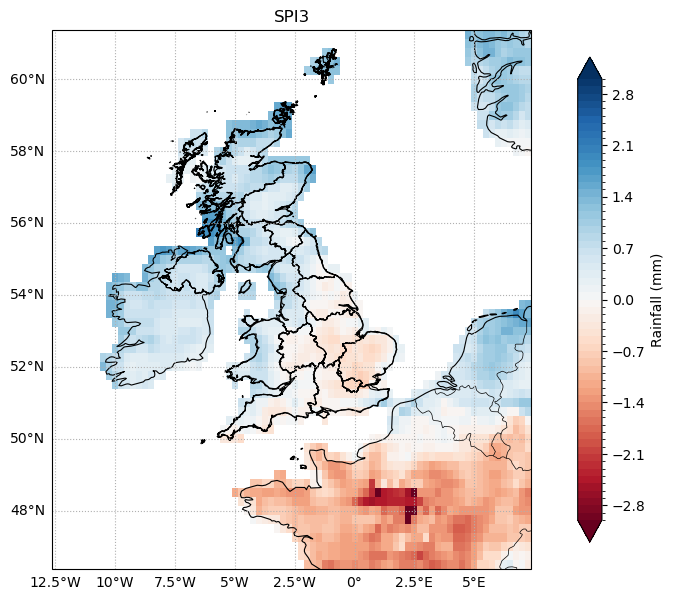

In [7]:
ERAR = UKspi3['SPI3'].sel(time='1998-08')

fig = plt.figure(figsize=(12, 7))
ax = plt.axes(projection=ccrs.PlateCarree())

levels = np.arange(-3, 3.1, 0.1)


cfa = ERAR.plot(
    ax=ax,
    levels=levels,
    cmap="RdBu",
    vmax=5,
    vmin=-5,
    #norm=norm,
    #cmap=cmap_pr,
    extend="both",
    add_colorbar=False,
    transform=ccrs.PlateCarree()
)


# Reproject gdf_regions to lat/lon (EPSG:4326) and plot boundaries
gdf_regions.to_crs(epsg=4326).plot(
    ax=ax,
    facecolor='none',       # Keep region interior transparent
    edgecolor='black',      # Border line color
    linewidth=0.8,          # Border line width
    transform=ccrs.PlateCarree()
)


ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
ax.add_feature(cfeature.BORDERS, linewidth=0.5)

gl = ax.gridlines(draw_labels=True, linestyle=':')
gl.top_labels = False
gl.right_labels = False

cbar = plt.colorbar(cfa, ax=ax, shrink=0.9)
cbar.set_label("Rainfall (mm)")
ax.set_aspect(1.5)

plt.title("SPI3")
plt.show()

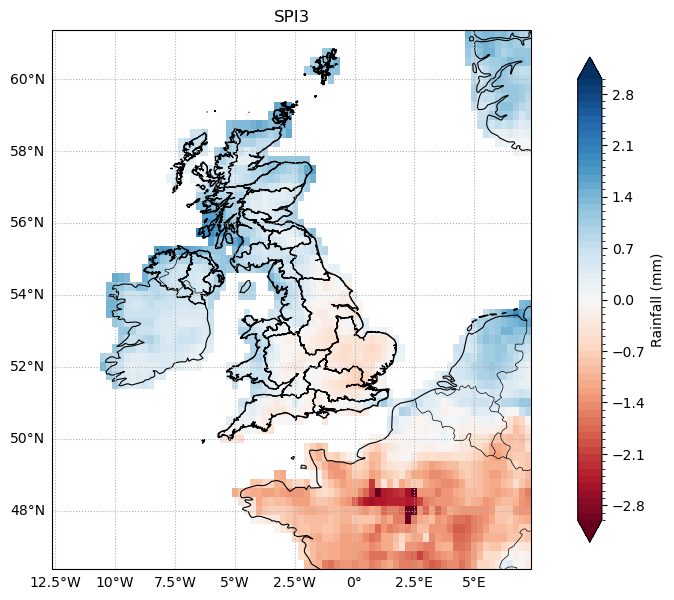

In [8]:
ERAR = UKspi3['SPI3'].sel(time='1998-08')

fig = plt.figure(figsize=(12, 7))
ax = plt.axes(projection=ccrs.PlateCarree())

levels = np.arange(-3, 3.1, 0.1)


cfa = ERAR.plot(
    ax=ax,
    levels=levels,
    cmap="RdBu",
    vmax=5,
    vmin=-5,
    #norm=norm,
    #cmap=cmap_pr,
    extend="both",
    add_colorbar=False,
    transform=ccrs.PlateCarree()
)


# Reproject gdf_regions to lat/lon (EPSG:4326) and plot boundaries
gdf_rivers.to_crs(epsg=4326).plot(
    ax=ax,
    facecolor='none',       # Keep region interior transparent
    edgecolor='black',      # Border line color
    linewidth=0.8,          # Border line width
    transform=ccrs.PlateCarree()
)


ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
ax.add_feature(cfeature.BORDERS, linewidth=0.5)

gl = ax.gridlines(draw_labels=True, linestyle=':')
gl.top_labels = False
gl.right_labels = False

cbar = plt.colorbar(cfa, ax=ax, shrink=0.9)
cbar.set_label("Rainfall (mm)")
ax.set_aspect(1.5)

plt.title("SPI3")
plt.show()

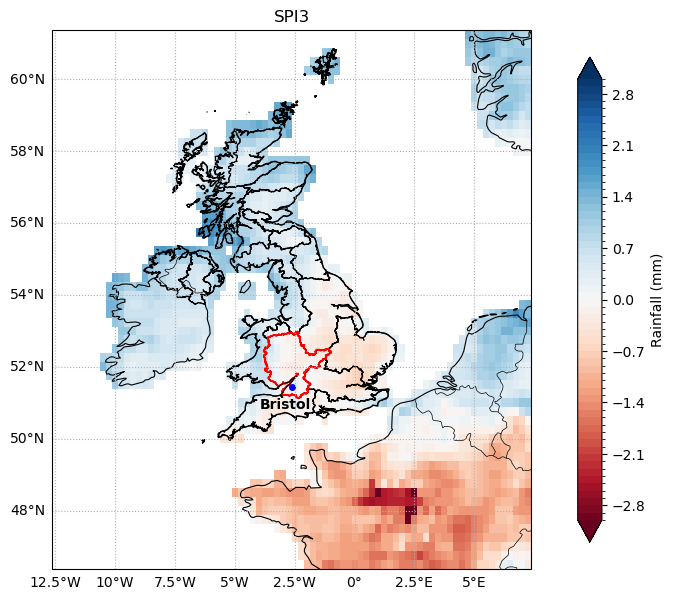

In [9]:
ERAR = UKspi3['SPI3'].sel(time='1998-08')

fig = plt.figure(figsize=(12, 7))
ax = plt.axes(projection=ccrs.PlateCarree())

levels = np.arange(-3, 3.1, 0.1)


cfa = ERAR.plot(
    ax=ax,
    levels=levels,
    cmap="RdBu",
    vmax=5,
    vmin=-5,
    #norm=norm,
    #cmap=cmap_pr,
    extend="both",
    add_colorbar=False,
    transform=ccrs.PlateCarree()
)


# Reproject gdf_regions to lat/lon (EPSG:4326) and plot boundaries
gdf_rivers.to_crs(epsg=4326).plot(
    ax=ax,
    facecolor='none',       # Keep region interior transparent
    edgecolor='black',      # Border line color
    linewidth=0.8,          # Border line width
    transform=ccrs.PlateCarree()
)

## Draw Severn polygon
gdf_rivers.to_crs(epsg=4326).loc[
    gdf_rivers["geo_region"] == "Severn"
].plot(
    ax=ax,
    facecolor='none',       # Keep region interior transparent
    edgecolor='red',      # Border line color
    linewidth=1.2,          # Border line width
    transform=ccrs.PlateCarree()
)

ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
ax.add_feature(cfeature.BORDERS, linewidth=0.5)

# --- Add point at Bristol ---
bristol_lat, bristol_lon = 51.4536, -2.5975
ax.plot(
    bristol_lon,
    bristol_lat,
    marker="o",
    color="blue",
    markersize=4,
    transform=ccrs.PlateCarree(),
    label="Bristol",
)
ax.text(
    bristol_lon - 1.35,
    bristol_lat-0.5,
    "Bristol",
    fontsize=10,
    fontweight="bold",
    transform=ccrs.PlateCarree(),
    verticalalignment="center",
)
# -----------------------------

gl = ax.gridlines(draw_labels=True, linestyle=':')
gl.top_labels = False
gl.right_labels = False

cbar = plt.colorbar(cfa, ax=ax, shrink=0.9)
cbar.set_label("Rainfall (mm)")
ax.set_aspect(1.5)

plt.title("SPI3")
plt.show()

In [10]:
tsBristol = UKspei3['SPEI3'].sel(lat=51.4536, lon=-2.5975,method='nearest')

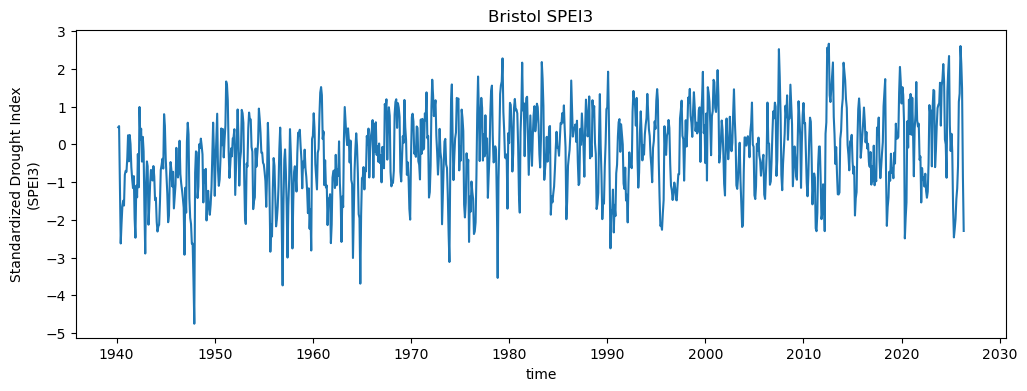

In [11]:
tsBristol.plot(figsize=(12, 4)) 
plt.title("Bristol SPEI3")
plt.show()

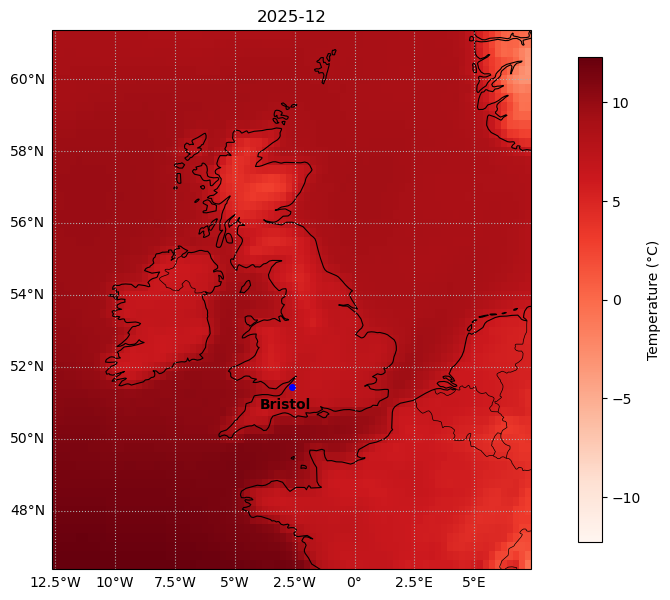

In [12]:
MyDate='2025-12'

fig = plt.figure(figsize=(12, 7))
ax = plt.axes(projection=ccrs.PlateCarree())

cfa = (xrt2c['t2m'].sel(valid_time=MyDate)-273.15).plot(ax=ax,add_colorbar=False,cmap='Reds')

ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
ax.add_feature(cfeature.BORDERS, linewidth=0.5)


# --- Add point at Bristol ---
bristol_lat, bristol_lon = 51.4536, -2.5975
ax.plot(
    bristol_lon,
    bristol_lat,
    marker="o",
    color="blue",
    markersize=4,
    transform=ccrs.PlateCarree(),
    label="Bristol",
)
ax.text(
    bristol_lon - 1.35,
    bristol_lat-0.5,
    "Bristol",
    fontsize=10,
    fontweight="bold",
    transform=ccrs.PlateCarree(),
    verticalalignment="center",
)
# -----------------------------

plt.title(MyDate)

gl = ax.gridlines(draw_labels=True, linestyle=':')
gl.top_labels = False
gl.right_labels = False

cbar = plt.colorbar(cfa, ax=ax, shrink=0.9)
cbar.set_label("Temperature (°C)")
ax.set_aspect(1.5)


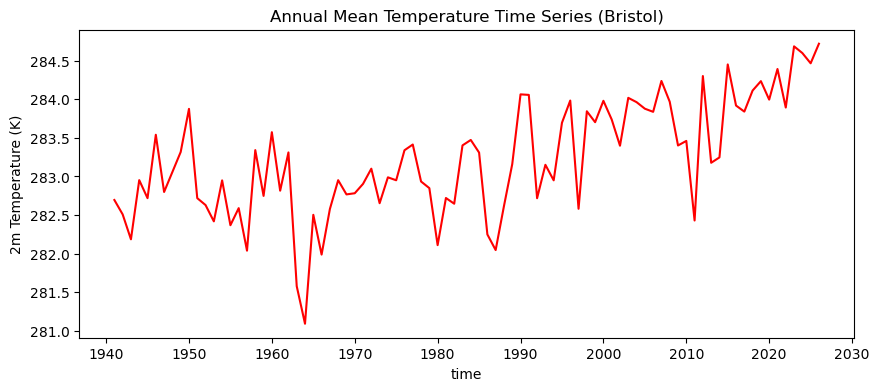

In [13]:
# --- Temperature (t2m) ---
# Select nearest coordinates using 'latitude' and 'longitude'
t2m_B = xrt2c["t2m"].sel(latitude=51.4536, longitude=-2.5975, method="nearest")
# Resample annually (using year-end 'YE') and compute the annual mean
t2m_annual_mean = t2m_B.resample(valid_time="YE").mean()

# --- Total Precipitation (tp) ---
# Select nearest point (uses 'latitude' and 'longitude')
tp_B = xrpc["tp"].sel(latitude=51.4536, longitude=-2.5975, method="nearest")
# Calculate annual total precipitation (summing across the year)
tp_annual = tp_B.resample(valid_time="YE").sum()


# --- SPEI3 ---
# Select nearest point (uses 'lat' and 'lon')
spei3_B = UKspei3["SPEI3"].sel(lat=51.4536, lon=-2.5975, method="nearest")
# Calculate annual mean SPEI3
spei3_annual = spei3_B.resample(time="YE").mean()

# 3. Plot the annual mean time series
t2m_annual_mean.plot(figsize=(10, 4),color='red')
plt.ylabel("2m Temperature (K)")
plt.title("Annual Mean Temperature Time Series (Bristol)")
plt.show()

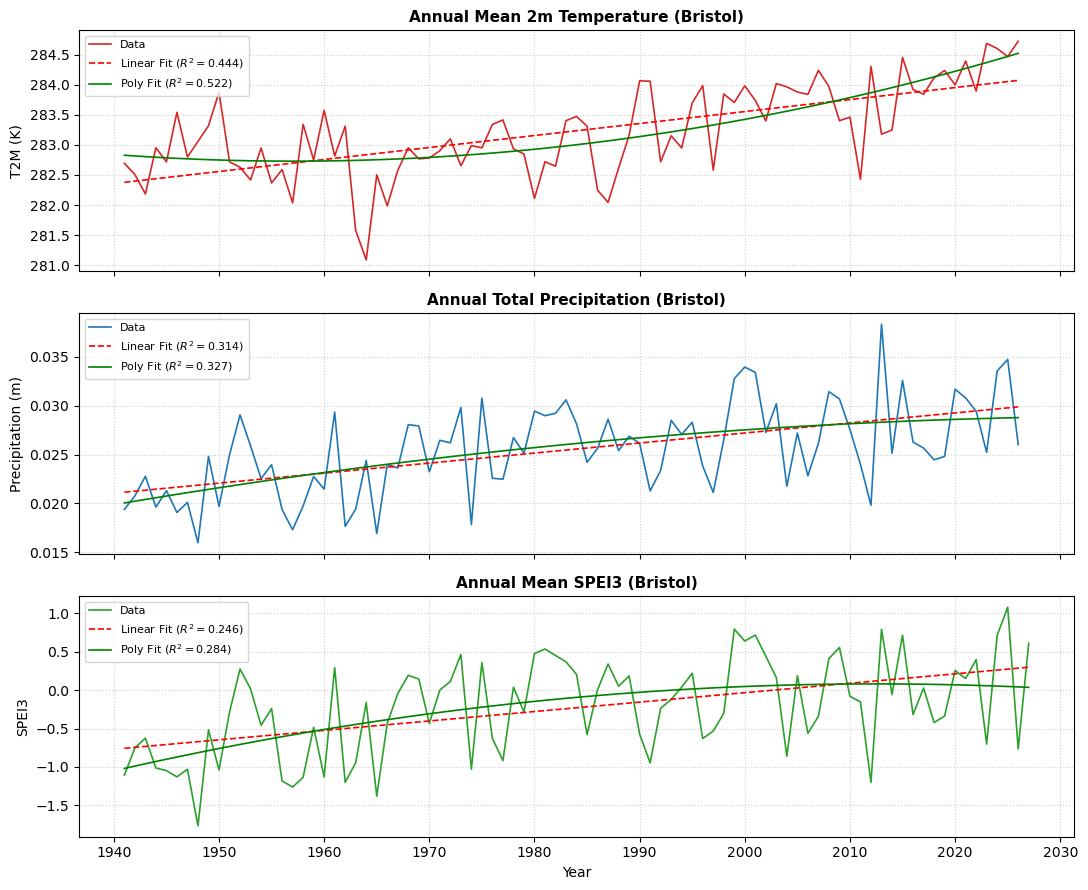

In [14]:
def fit_and_plot(ax, da, ylabel, title, color="tab:blue"):
    """Helper function to plot a time series with linear and polynomial trend lines."""
    # Retrieve the primary time coordinate dynamic dimension name
    time_dim = da.dims[0]
    time_coords = da[time_dim].values
    values = da.values

    # Clean NaNs
    valid_mask = ~np.isnan(values)
    y = values[valid_mask]
    t_valid = time_coords[valid_mask]

    # Convert to numeric years for fitting
    x_numeric = pd.to_datetime(t_valid).year.values

    # Linear Fit (Degree 1)
    p1 = np.polyfit(x_numeric, y, 1)
    y_lin = np.polyval(p1, x_numeric)
    r2_lin = 1 - (np.sum((y - y_lin) ** 2) / np.sum((y - np.mean(y)) ** 2))

    # Polynomial Fit (Degree 2)
    p2 = np.polyfit(x_numeric, y, 2)
    y_poly = np.polyval(p2, x_numeric)
    r2_poly = 1 - (np.sum((y - y_poly) ** 2) / np.sum((y - np.mean(y)) ** 2))

    # Plot data and trendlines
    ax.plot(t_valid, y, label="Data", color=color, linewidth=1.2)
    ax.plot(
        t_valid,
        y_lin,
        "r--",
        linewidth=1.2,
        label=f"Linear Fit ($R^2 = {r2_lin:.3f}$)",
    )
    ax.plot(
        t_valid,
        y_poly,
        "g-",
        linewidth=1.2,
        label=f"Poly Fit ($R^2 = {r2_poly:.3f}$)",
    )

    ax.set_ylabel(ylabel)
    ax.set_title(title, fontsize=11, fontweight="bold")
    ax.legend(loc="upper left", fontsize=8)
    ax.grid(True, linestyle=":", alpha=0.6)


# Create 3 vertically stacked subplots sharing the x-axis
fig, axes = plt.subplots(3, 1, figsize=(11, 9), sharex=True)

# 1. T2M Annual Mean
fit_and_plot(
    axes[0],
    t2m_annual_mean,
    ylabel="T2M (K)",
    title="Annual Mean 2m Temperature (Bristol)",
    color="tab:red",
)

# 2. Total Precipitation Annual Sum
fit_and_plot(
    axes[1],
    tp_annual,
    ylabel="Precipitation (m)",
    title="Annual Total Precipitation (Bristol)",
    color="tab:blue",
)

# 3. SPEI3 Annual Mean
fit_and_plot(
    axes[2],
    spei3_annual,
    ylabel="SPEI3",
    title="Annual Mean SPEI3 (Bristol)",
    color="tab:green",
)

axes[2].set_xlabel("Year")
plt.tight_layout()
plt.show()